In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q transformers datasets accelerate

import os
import re
import json
import time
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

BASE_DIR = '/content/drive/MyDrive/NLP_Final_Project_Final'
DATA_DIR = f'{BASE_DIR}/data/splits'
MODEL_DIR = f'{BASE_DIR}/models/indobert'
ARTIFACT_DIR = f'{BASE_DIR}/artifacts/indobert'

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("BASE_DIR   :", BASE_DIR)
print("DATA_DIR   :", DATA_DIR)
print("MODEL_DIR  :", MODEL_DIR)
print("ARTIFACT_DIR:", ARTIFACT_DIR)

BASE_DIR   : /content/drive/MyDrive/NLP_Final_Project_Final
DATA_DIR   : /content/drive/MyDrive/NLP_Final_Project_Final/data/splits
MODEL_DIR  : /content/drive/MyDrive/NLP_Final_Project_Final/models/indobert
ARTIFACT_DIR: /content/drive/MyDrive/NLP_Final_Project_Final/artifacts/indobert


In [ ]:
df_train = pd.read_csv(f'{DATA_DIR}/train_data.csv')
df_val   = pd.read_csv(f'{DATA_DIR}/val_data.csv')
df_test  = pd.read_csv(f'{DATA_DIR}/test_data.csv')

print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)

display(df_train.head())

Train: (7797, 4)
Val  : (975, 4)
Test : (975, 4)


,judul,text_clean,sentimen,label_id
0,Bos Garuda: Citilink Gabung Pelita Air Barenga...,bos garuda: citilink gabung pelita air barenga...,netral,1
1,Pesan Airlangga untuk Presiden Baru: Dunia Tid...,pesan airlangga untuk presiden baru: dunia tid...,netral,1
2,"Minta Restu Investor, Bank Mandiri (BMRI) Mau ...","minta restu investor, bank mandiri (bmri) mau ...",positif,2
3,"Segini Besaran Uang Pensiun Jokowi, Sudah Mula...","segini besaran uang pensiun jokowi, sudah mula...",netral,1
4,Ini Daftar Lengkap Jajaran Direksi dan Komisar...,ini daftar lengkap jajaran direksi dan komisar...,netral,1


In [ ]:
required_cols = ['judul', 'text_clean', 'sentimen', 'label_id']
for col in required_cols:
    for name, df_ in [('train', df_train), ('val', df_val), ('test', df_test)]:
        if col not in df_.columns:
            raise ValueError(f"Kolom '{col}' tidak ditemukan di {name}.")

print("Semua kolom penting tersedia.")

Semua kolom penting tersedia.


In [ ]:
preview_transformer = df_train[['judul', 'text_clean', 'sentimen']].sample(10, random_state=42).reset_index(drop=True)
display(preview_transformer)

preview_transformer.to_csv(
    f'{ARTIFACT_DIR}/preprocessing_preview_transformer.csv',
    index=False
)

,judul,text_clean,sentimen
0,"Trump Tunda Perang Dagang, Dolar Turun ke Rp 1...","trump tunda perang dagang, dolar turun ke rupi...",positif
1,"Terungkap, Jokowi Ketar-ketir Waktu Dolar AS S...","terungkap, jokowi ketar-ketir waktu dolar as s...",negatif
2,Krom Bank Andalkan Modal Dulu Buat Salurkan Kr...,krom bank andalkan modal dulu buat salurkan kr...,netral
3,"Robert Kiyosaki Ingatkan Nasib Buruk Dolar, Ka...","robert kiyosaki ingatkan nasib buruk dolar, ka...",netral
4,"Elon Musk Jadi Musuh Warga AS, Tesla Kena Boik...","elon musk jadi musuh warga as, tesla kena boik...",negatif
5,"Bank Mega Syariah Cetak Laba Rp253,19 M Sepanj...","bank mega syariah cetak laba rupiah 253,19 m s...",positif
6,"Investor Pelototi Tanda-Tanda dari AS, Harga M...","investor pelototi tanda-tanda dari as, harga m...",netral
7,Emiten Suami Puan (CBRE) Targetkan Lonjakan Pe...,emiten suami puan (cbre) targetkan lonjakan pe...,positif
8,"Jensen Huang Lego Besar-Besaran, Saham Nvidia ...","jensen huang lego besar-besaran, saham nvidia ...",negatif
9,Alasan Danantara Angkat Tokoh Global Jadi Dewa...,alasan danantara angkat tokoh global jadi dewa...,netral


In [ ]:
for i in range(5):
    print(f"Contoh ke-{i+1}")
    print("ASLI      :", preview_transformer.loc[i, 'judul'])
    print("TEXT_CLEAN:", preview_transformer.loc[i, 'text_clean'])
    print("LABEL     :", preview_transformer.loc[i, 'sentimen'])
    print("-" * 120)

Contoh ke-1
ASLI      : Trump Tunda Perang Dagang, Dolar Turun ke Rp 16.360
TEXT_CLEAN: trump tunda perang dagang, dolar turun ke rupiah 16.360
LABEL     : positif
------------------------------------------------------------------------------------------------------------------------
Contoh ke-2
ASLI      : Terungkap, Jokowi Ketar-ketir Waktu Dolar AS Sempat Tembus Rp16.200
TEXT_CLEAN: terungkap, jokowi ketar-ketir waktu dolar as sempat tembus rupiah 16.200
LABEL     : negatif
------------------------------------------------------------------------------------------------------------------------
Contoh ke-3
ASLI      : Krom Bank Andalkan Modal Dulu Buat Salurkan Kredit
TEXT_CLEAN: krom bank andalkan modal dulu buat salurkan kredit
LABEL     : netral
------------------------------------------------------------------------------------------------------------------------
Contoh ke-4
ASLI      : Robert Kiyosaki Ingatkan Nasib Buruk Dolar, Kasih Saran Ini Agar Kaya
TEXT_CLEAN: robert kiyosa

In [ ]:
train_dataset = Dataset.from_dict({
    'text': df_train['text_clean'].tolist(),
    'labels': df_train['label_id'].tolist()
})

val_dataset = Dataset.from_dict({
    'text': df_val['text_clean'].tolist(),
    'labels': df_val['label_id'].tolist()
})

test_dataset = Dataset.from_dict({
    'text': df_test['text_clean'].tolist(),
    'labels': df_test['label_id'].tolist()
})

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'labels'],
    num_rows: 7797
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 975
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 975
})


Load Tokenizer

In [ ]:
model_name = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded:", model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: indobenchmark/indobert-base-p2


In [ ]:
MAX_LEN = 64

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN
    )

In [ ]:
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val   = val_dataset.map(tokenize_function, batched=True)
tokenized_test  = test_dataset.map(tokenize_function, batched=True)

print(tokenized_train)

Map:   0%|          | 0/7797 [00:00<?, ? examples/s]

Map:   0%|          | 0/975 [00:00<?, ? examples/s]

Map:   0%|          | 0/975 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 7797
})


In [ ]:
sample_idx = 0

sample_text = df_train.loc[sample_idx, 'text_clean']
encoded_sample = tokenizer(sample_text, truncation=True, max_length=MAX_LEN)

print("TEXT_CLEAN:")
print(sample_text)
print("\nTOKENS:")
print(tokenizer.convert_ids_to_tokens(encoded_sample['input_ids']))
print("\nINPUT_IDS:")
print(encoded_sample['input_ids'])
print("\nATTENTION_MASK:")
print(encoded_sample['attention_mask'])

TEXT_CLEAN:
bos garuda: citilink gabung pelita air barengan dengan injourney

TOKENS:
['[CLS]', 'bos', 'garuda', ':', 'citilink', 'gabung', 'pelita', 'air', 'bareng', '##an', 'dengan', 'inj', '##our', '##ney', '[SEP]']

INPUT_IDS:
[2, 3235, 7102, 30472, 27706, 12198, 18028, 514, 8074, 5, 79, 5335, 6941, 7361, 3]

ATTENTION_MASK:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
id2label = {
    0: 'negatif',
    1: 'netral',
    2: 'positif'
}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print("Model loaded.")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.


Weighted loss

In [ ]:
class_counts = df_train['label_id'].value_counts().sort_index().values
total_samples = len(df_train)

class_weights = total_samples / (len(class_counts) * class_counts)
weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("Class counts :", class_counts)
print("Class weights:", class_weights)

Class counts : [2047 3441 2309]
Class weights: [1.26966292 0.75530369 1.1255955 ]


In [ ]:
label_names = ['negatif', 'netral', 'positif']

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average='macro')
    return {"macro_f1": macro_f1}

def compute_metrics_full(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy': acc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted
    }

def plot_and_save_confusion_matrix(cm, labels, title, save_path):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, str(cm[i, j]),
                ha='center',
                color='white' if cm[i, j] > threshold else 'black'
            )

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(weight=weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir=f'{ARTIFACT_DIR}/checkpoints',
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    seed=42,
    report_to="none",
    fp16=torch.cuda.is_available()
)

In [ ]:
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

print("Trainer siap.")

Trainer siap.


In [ ]:
start_train = time.time()
train_result = trainer.train()
train_time_sec = time.time() - start_train

print(f"Training selesai dalam {train_time_sec:.2f} detik")

Epoch,Training Loss,Validation Loss,Macro F1
1,0.509367,0.423743,0.852244
2,0.196321,0.393803,0.891975
3,0.074037,0.507836,0.893327


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training selesai dalam 216.74 detik


In [ ]:
predictions = trainer.predict(tokenized_test)
preds = np.argmax(predictions.predictions, axis=-1)
y_test = df_test['label_id'].tolist()

metrics_full = compute_metrics_full(y_test, preds)
cm = confusion_matrix(y_test, preds)

print("Accuracy   :", round(metrics_full['accuracy'], 4))
print("Macro Prec :", round(metrics_full['precision_macro'], 4))
print("Macro Rec  :", round(metrics_full['recall_macro'], 4))
print("Macro F1   :", round(metrics_full['f1_macro'], 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    preds,
    target_names=label_names,
    zero_division=0
))

Accuracy   : 0.8769
Macro Prec : 0.8738
Macro Rec  : 0.8838
Macro F1   : 0.8781

Classification Report:
              precision    recall  f1-score   support

     negatif       0.85      0.92      0.89       256
      netral       0.90      0.84      0.87       430
     positif       0.87      0.89      0.88       289

    accuracy                           0.88       975
   macro avg       0.87      0.88      0.88       975
weighted avg       0.88      0.88      0.88       975



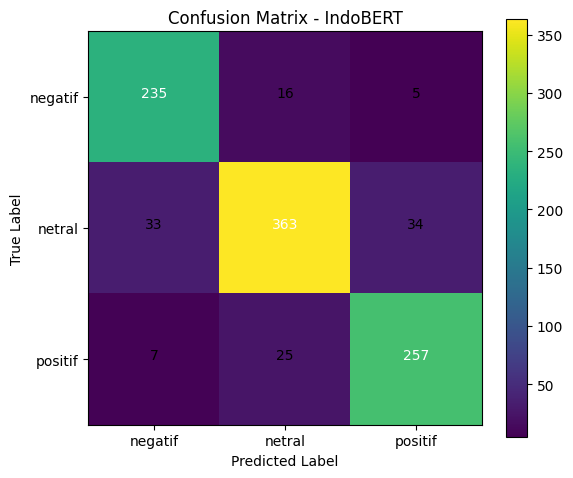

In [ ]:
plot_and_save_confusion_matrix(
    cm,
    label_names,
    title='Confusion Matrix - IndoBERT',
    save_path=f'{ARTIFACT_DIR}/confusion_matrix_indobert.png'
)

In [ ]:
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print("Model dan tokenizer berhasil disimpan ke:")
print(MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan tokenizer berhasil disimpan ke:
/content/drive/MyDrive/NLP_Final_Project_Final/models/indobert


In [ ]:
summary_df = pd.DataFrame([{
    'model': 'IndoBERT',
    'checkpoint': model_name,
    'learning_rate': 3e-5,
    'batch_size': 16,
    'epochs': 3,
    'accuracy': metrics_full['accuracy'],
    'precision_macro': metrics_full['precision_macro'],
    'recall_macro': metrics_full['recall_macro'],
    'f1_macro': metrics_full['f1_macro'],
    'train_time_sec': train_time_sec
}])

summary_df.to_csv(f'{ARTIFACT_DIR}/indobert_metrics_summary.csv', index=False)
display(summary_df)

,model,checkpoint,learning_rate,batch_size,epochs,accuracy,precision_macro,recall_macro,f1_macro,train_time_sec
0,IndoBERT,indobenchmark/indobert-base-p2,0.00003,16,3,0.876923,0.873768,0.883809,0.878086,216.740292


In [ ]:
report_dict = classification_report(
    y_test,
    preds,
    target_names=label_names,
    zero_division=0,
    output_dict=True
)

with open(f'{ARTIFACT_DIR}/indobert_classification_report.json', 'w') as f:
    json.dump(report_dict, f, indent=2)

pred_df = df_test[['judul', 'text_clean', 'sentimen', 'label_id']].copy()
pred_df['pred_label_id'] = preds
pred_df['pred_sentimen'] = pred_df['pred_label_id'].map(id2label)
pred_df['is_correct'] = pred_df['label_id'] == pred_df['pred_label_id']

pred_df.to_csv(f'{ARTIFACT_DIR}/indobert_test_predictions.csv', index=False)

print("Artifacts evaluasi berhasil disimpan.")

Artifacts evaluasi berhasil disimpan.


In [ ]:
print("Contoh prediksi BENAR:")
display(pred_df[pred_df['is_correct'] == True].sample(5, random_state=42))

print("Contoh prediksi SALAH:")
display(pred_df[pred_df['is_correct'] == False].sample(5, random_state=42))

Contoh prediksi BENAR:


,judul,text_clean,sentimen,label_id,pred_label_id,pred_sentimen,is_correct
75,"Laba Emiten Telko Ini Terbang 878,5%, Ini Pemi...","laba emiten telko ini terbang 878,5 persen , i...",positif,2,2,positif,True
499,"Inflasi Produsen AS Melandai, Wall Street Dibu...","inflasi produsen as melandai, wall street dibu...",positif,2,2,positif,True
225,Nasib Rupiah Kini Bergantung Keputusan Suku Bu...,nasib rupiah kini bergantung keputusan suku bu...,netral,1,1,netral,True
244,"IHSG Dihajar Sentimen Dalam dan Luar Negeri, A...","ihsg dihajar sentimen dalam dan luar negeri, a...",negatif,0,0,negatif,True
904,"Mengenal IndONIA, Full Gantikan JIBOR BI Mulai...","mengenal indonia, full gantikan jibor bi mulai...",netral,1,1,netral,True


Contoh prediksi SALAH:


,judul,text_clean,sentimen,label_id,pred_label_id,pred_sentimen,is_correct
347,Ada Tiga BUMN Siapkan Lahan Program 3 Juta Rum...,ada tiga bumn siapkan lahan program 3 juta rum...,positif,2,1,netral,False
372,"Ketakutan Terbesar Jokowi Jadi Kenyataan, Bank...","ketakutan terbesar jokowi jadi kenyataan, bank...",netral,1,0,negatif,False
36,Indonesia Punya Operator Bandara Terbesar Nomo...,indonesia punya operator bandara terbesar nomo...,positif,2,1,netral,False
446,"The Fed Bakal Pangkas Suku Bunga 25 Bps, Intip...","the fed bakal pangkas suku bunga 25 bps, intip...",netral,1,2,positif,False
216,"PBNU Mau Borong Tanah 100 Hektare di IKN, Nila...","pbnu mau borong tanah 100 hektare di ikn, nila...",netral,1,2,positif,False
